# Diffusion Models

Diffusion models create new data that resembles their training set through a repeated cycle of applying and then removing noise.

They have been explored as an alternate to other generative frameworks, such as GANs and VAEs.

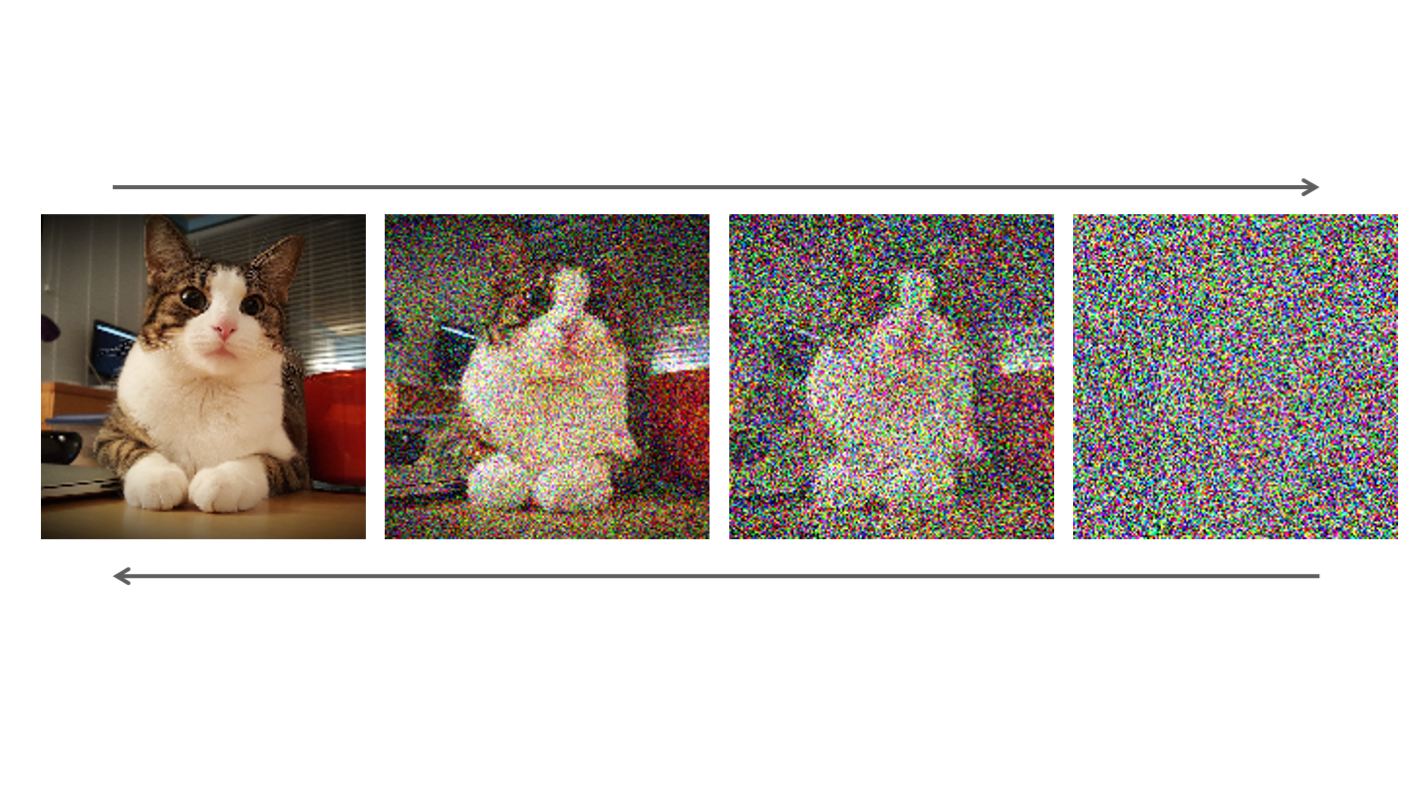

Image taken from [here](https://developer.nvidia.com/blog/improving-diffusion-models-as-an-alternative-to-gans-part-2/)


Diffusion models have evolved significantly from their traditional roots in image processing, where they were primarily employed for tasks like noise reduction and image restoration. These early methods relied on hand-crafted mathematical models to describe the diffusion process. However, the advent of deep learning marked a transformative shift. By leveraging neural networks, diffusion models can now learn the intricacies of the diffusion process directly from data, unlocking their potential for a vast array of applications, particularly in the generative modeling domain.

## Setup

This notebook runs a compact DDPM-style diffusion model on MNIST.

In [ ]:
!pip install -q torch torchvision tqdm torchinfo matplotlib numpy pandas

In [ ]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchinfo
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
from tqdm.auto import tqdm


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed: int = 0):
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Forward (noising) and Reverse (denoising)

Diffusion models learn to denoise images through two stages.

1. Forward (noising) process: We start with a clean image x₀ (for example, a digit from MNIST). Then, step by step, we add a small amount of Gaussian noise. If we keep doing this for many steps, the image eventually becomes indistinguishable from pure noise. This process is fixed and does not involve learning.

2. Reverse (denoising) process: We train a neural network to undo this corruption. Given a noisy image x_t and the time step t, the model tries to predict the noise that was added. By gradually removing noise step by step, the model learns to transform random noise into a meaningful image.

This makes diffusion models conceptually similar to VAEs (probabilistic) and GANs (image generation), but their training is much more stable: instead of a complicated adversarial game, we just use a simple regression loss.

**Key equation (DDPM):**

* Forward (closed form): $ x_t = \sqrt{\bar{α_t}} * x_0 + \sqrt{1 - \bar{α_t}} * ϵ $
* Training target: predict `eps` (the noise) given $x\_t$ and $t$.


Below we’ll try this in practice: take an MNIST digit, pick a timestep, and generate the corresponding noisy image.

In [ ]:
# Sample x_t from x0 using the closed-form
def make_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

set_seed(42)

T = 1000
betas = make_beta_schedule(T).to(DEVICE)
alphas = 1. - betas
alpha_bars = torch.cumprod(alphas, dim=0)

# Load one MNIST sample
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist = datasets.MNIST(root='data', train=True, download=True, transform=transform)
x0, _ = mnist[0]
x0 = x0.to(DEVICE).unsqueeze(0)  # add batch dimension

# Forward process: sample x_t from q(x_t | x_0)
t = 50  # example timestep
sqrt_alpha_bar = alpha_bars[t].sqrt().view(1, 1, 1, 1)
sqrt_one_minus_alpha_bar = (1 - alpha_bars[t]).sqrt().view(1, 1, 1, 1)

eps = torch.randn_like(x0)
xt = sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * eps

# Visualize
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.title('x₀')
plt.imshow((x0.cpu().squeeze() * 0.5 + 0.5), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'x_t (t={t})')
plt.imshow((xt.cpu().squeeze() * 0.5 + 0.5), cmap='gray')
plt.axis('off')

plt.show()

## Small UNet-like network

The model needs to know the current timestep `t`. We'll embed `t` to a vector (sinusoidal embedding) and feed it into a small convolutional U-Net-ish model. This technique transforms the raw timestep into a rich, continuous representation that captures both absolute and relative temporal information. For this example we use a compact model: a sequence of conv blocks with residual connections.

In [ ]:
# Sinusoidal timestep embedding
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.exp(torch.arange(half_dim, device=device) * -(math.log(10000.0) / (half_dim - 1)))
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

# Small conv block
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.act = nn.GELU()
        self.norm = nn.GroupNorm(1, out_ch)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch) if time_emb_dim else None

        # 1x1 conv for residual if needed
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb=None):
        h = self.act(self.norm(self.conv1(x)))
        if t_emb is not None:
            h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.conv2(h)
        return self.act(h + self.res_conv(x))

# Tiny UNet-like model for MNIST
class TinyUNet(nn.Module):
    def __init__(self, ch=32, emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.GELU()
        )

        self.init = nn.Conv2d(1, ch, 3, padding=1)
        self.down1 = Block(ch, ch, emb_dim)
        self.mid = Block(ch, ch, emb_dim)
        self.up1 = Block(ch, ch, emb_dim)
        self.final = nn.Conv2d(ch, 1, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        h = self.init(x)
        h = self.down1(h, t_emb)
        h = self.mid(h, t_emb)
        h = self.up1(h, t_emb)
        return self.final(h)


torchinfo.summary(TinyUNet(), input_data=(torch.zeros(1,1,28,28), torch.zeros(1,dtype=torch.long)))

## Training objective (predicting noise)

We'll train the model to predict the noise `eps` using MSE loss: `loss = || eps - eps_theta(x_t, t) ||^2`. The training step samples a random `t` for each batch and uses the closed form to compute `x_t`.

In [ ]:
# Precompute schedules as tensors on device
T = 1000
betas = make_beta_schedule(T).to(DEVICE)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

# Sample x_t and eps given x0 and t
def q_sample(x0, t, noise=None):
    # x0: [B,C,H,W], t: [B]
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alpha_bar = alpha_bars[t].sqrt().view(-1,1,1,1)
    sqrt_one_minus_alpha_bar = (1 - alpha_bars[t]).sqrt().view(-1,1,1,1)
    return sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise, noise

# Reverse denoising loop (simple ancestral sampling)
@torch.no_grad()
def sample(model, n=16):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=DEVICE)
    for i in reversed(range(T)):
        t = torch.full((n,), i, device=DEVICE, dtype=torch.long)
        eps_theta = model(x, t)

        alpha = alphas[t].view(-1, 1, 1, 1)
        alpha_bar = alpha_bars[t].view(-1, 1, 1, 1)
        beta = betas[t].view(-1, 1, 1, 1)

        # mean (μθ) term from Algorithm 2
        mean = (1 / torch.sqrt(alpha)) * (
            x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * eps_theta
        )

        # sample z ~ N(0, I) if t > 0
        if i > 0:
            z = torch.randn_like(x)
            sigma_t = torch.sqrt(beta)
            x = mean + sigma_t * z
        else:
            x = mean

    x = torch.clamp(x, -1.0, 1.0)
    model.train()
    return x

## Visualise outputs

In [ ]:
def simple_visualize(model, dataloader, n=8):
    """Simple grid comparison"""
    model.eval()

    # Get real samples
    real_batch, _ = next(iter(dataloader))
    real_batch = real_batch[:n].to(DEVICE)

    # Generate samples
    with torch.no_grad():
        generated = sample(model, n=n)

    # Create combined grid
    real_grid = make_grid((real_batch.cpu() + 1) / 2, nrow=n)
    gen_grid = make_grid((generated.cpu() + 1) / 2, nrow=n)

    # Plot side by side
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(real_grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.title('Real MNIST Digits')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(gen_grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.title('Generated Digits')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    model.train()

# Coursework


## Task 1:

In diffusion models, images are gradually corrupted with Gaussian noise. Your task is to implement a function that adds noise to the images given a time step.
Fill in the missing code in the add_noise() function and generate some noised images, almost to the point where the original image is unrecognisable.

**Submission**

*   Include the clean image, the noised image and the noise itself.


    File name: `CID_E7_T1_Noise.png`



In [ ]:
def add_noise(x: torch.Tensor, t: torch.Tensor, sqrt_alphas_cumprod: torch.Tensor, sqrt_one_minus_alphas_cumprod: torch.Tensor):
    """
    Add noise to input images according to the diffusion process.

    Args:
        x: torch.Tensor
            Original clean images (batch_size, channels, height, width).
        t: torch.Tensor
            Time steps for each image in the batch (batch_size,).
        sqrt_alphas_cumprod: torch.Tensor
            Precomputed square root of cumulative product of alphas.
        sqrt_one_minus_alphas_cumprod: torch.Tensor
            Precomputed square root of (1 - cumulative product of alphas).

    Returns:
        x_noisy: torch.Tensor
            The noisy images at time step t.
        noise: torch.Tensor
            The Gaussian noise that was added.
    """

## Task 2: Class-conditioned generation

The model above learns to generate MNIST-like digits, but it is not told which digit to make. In this task you will add class conditioning so that the model receives both the noisy image and the target digit label.

From Task 1 and the earlier diffusion cells, you already have the diffusion ingredients:

```text
x_0 = clean MNIST image
noise = Gaussian noise
t = diffusion timestep
x_t = noised image at timestep t
model(x_t, t) = predicted noise
```

Class conditioning adds one more input:

```python
model(x_t, t, y) -> predicted_noise
```

Here `y` is the digit label, from 0 to 9. The model turns `y` into a learned label embedding and combines it with the timestep embedding. The objective stays the same: minimise MSE between the predicted noise and the true noise used to corrupt the image.

### Problem Definition

Design and train a conditional DDPM denoiser for MNIST. Keep the original `TinyUNet` intact, add a label-conditioned model, train it with the fixed noise-prediction objective, and generate a fixed-seed sample grid with 10 rows, one row for each digit class.

Keep the supplied `ConditionalTinyUNet` class name, forward signature and checkpoint format fixed so the loading and checking cells can reconstruct the model from metadata. Do not introduce a layer layout that cannot be rebuilt from `TASK2_COND_CHANNELS` and `TASK2_COND_EMB_DIM`. Do not change the MNIST dataset, noise schedule, target, loss function, or checkpoint interface.

**Submission**:

Submit the following artefacts using the CID file names below; a brief description of each file is shown in parentheses. Naming key: `M` = model or adapter, `D` = data/CSV/JSON/log, `P` = plot/figure, `W` = written answer.

1. A loadable class-conditioned checkpoint.

    File Name: `CID_E9_T2_M1.pt` (trained class-conditioned DDPM checkpoint)

2. Metadata needed to rebuild the checkpoint.

    File Name: `CID_E9_T2_D1.json` (model architecture and training metadata)

3. The conditional training loss figure.

    File Name: `CID_E9_T2_P1.png` (conditional DDPM training-loss curve)

4. The conditional training log.

    File Name: `CID_E9_T2_D2.csv` (step-by-step conditional training log)

5. A conditional sample grid with 10 rows, one row per digit class.

    File Name: `CID_E9_T2_P2.png` (fixed-seed sample grid for digit classes 0–9)

6. One short paragraph discussing visible failures such as class confusion, low diversity or blurry samples.

    File Name: `CID_E9_T2_W1.txt` (brief discussion of visible generation failures)

### Rerunnable Task 2 workflow

Run the conditional model-definition cell once after checking or completing the class-conditioning implementation. Then rerun the fixed training/checkpoint cell, followed by the checkpoint-loading and class-grid cell. The training cell saves the checkpoint and metadata used by Task 3.


#### Conditional model cell

Run this cell after checking or completing the class-conditioning implementation. It defines `ConditionalTinyUNet`, keeps the earlier timestep embedding, adds `nn.Embedding(10, emb_dim)` for digit labels, and combines the two embeddings before each convolutional block. The tiny forward check verifies the required signature:

```python
model(x_t, t, y)
```

A correct output has the same shape as the noise target: `(batch, 1, 28, 28)`.


In [ ]:
import json


class ConditionalTinyUNet(nn.Module):
    def __init__(self, ch=32, emb_dim=128, num_classes=10):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
        )
        self.label_emb = nn.Embedding(num_classes, emb_dim)

        self.init = nn.Conv2d(1, ch, 3, padding=1)
        self.down1 = Block(ch, ch, emb_dim)
        self.downsample = nn.Conv2d(ch, ch * 2, 4, stride=2, padding=1)
        self.down2 = Block(ch * 2, ch * 2, emb_dim)
        self.mid = Block(ch * 2, ch * 2, emb_dim)
        self.upsample = nn.ConvTranspose2d(ch * 2, ch, 4, stride=2, padding=1)
        self.up1 = Block(ch, ch, emb_dim)
        self.final = nn.Conv2d(ch, 1, 1)

    def forward(self, x, t, y):
        t_emb = self.time_mlp(t)
        y_emb = self.label_emb(y)
        emb = t_emb + y_emb
        h0 = self.init(x)
        h1 = self.down1(h0, emb)
        h = self.downsample(h1)
        h = self.down2(h, emb)
        h = self.mid(h, emb)
        h = self.upsample(h)
        h = self.up1(h + h1, emb)
        return self.final(h)


conditional_model_preview = ConditionalTinyUNet().to(DEVICE)
torchinfo.summary(
    conditional_model_preview,
    input_data=(
        torch.zeros(1, 1, 28, 28, device=DEVICE),
        torch.zeros(1, dtype=torch.long, device=DEVICE),
        torch.zeros(1, dtype=torch.long, device=DEVICE),
    ),
)

#### Fixed training/checkpoint cell

Run this cell after the conditional model cell. It trains the conditional denoiser with the fixed objective. For every MNIST batch it samples a random timestep, adds Gaussian noise, passes both `t` and label `y` to the model, and minimises MSE against the exact noise that was added.

The checkpoint stores three things: model weights, metadata and loss history. The metadata is not the model itself, but it records the run configuration needed to reload the model.


In [ ]:
import csv

TASK2_COND_BATCH_SIZE = 128
TASK2_COND_LR = 2e-4
TASK2_COND_EPOCHS = 3
TASK2_COND_MAX_STEPS = 1000
TASK2_COND_CHANNELS = 32
TASK2_COND_EMB_DIM = 128
TASK2_COND_CKPT_PATH = Path("conditional_tinyunet_mnist.pt")
TASK2_COND_METADATA_PATH = Path("conditional_tinyunet_mnist_metadata.json")

sqrt_alphas_cumprod = alpha_bars.sqrt()
sqrt_one_minus_alphas_cumprod = (1 - alpha_bars).sqrt()


def build_mnist_loader(batch_size=TASK2_COND_BATCH_SIZE):
    return torch.utils.data.DataLoader(
        mnist,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=2 if DEVICE.type == "cuda" else 0,
        pin_memory=DEVICE.type == "cuda",
    )


def train_conditional_ddpm(
    model,
    dataloader,
    epochs=TASK2_COND_EPOCHS,
    max_steps=TASK2_COND_MAX_STEPS,
    lr=TASK2_COND_LR,
    ckpt_path=TASK2_COND_CKPT_PATH,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_history = []
    step = 0
    model.to(DEVICE)

    progress = tqdm(total=max_steps, desc="Training conditional DDPM")
    for epoch in range(epochs):
        model.train()
        for x0, y in dataloader:
            x0 = x0.to(DEVICE)
            y = y.to(DEVICE)
            t = torch.randint(0, T, (x0.size(0),), device=DEVICE).long()
            noise = torch.randn_like(x0)
            x_t = (
                sqrt_alphas_cumprod[t].view(-1, 1, 1, 1) * x0
                + sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) * noise
            )

            pred_noise = model(x_t, t, y)
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_history.append(float(loss.detach().cpu()))
            step += 1
            progress.update(1)
            progress.set_postfix(epoch=epoch + 1, loss=loss_history[-1])
            if step >= max_steps:
                break
        if step >= max_steps:
            break
    progress.close()

    metadata = {
        "model": "ConditionalTinyUNet",
        "config": {
            "ch": TASK2_COND_CHANNELS,
            "emb_dim": TASK2_COND_EMB_DIM,
            "num_classes": 10,
        },
        "dataset": "MNIST train split",
        "objective": "MSE predicted noise vs true noise",
        "epochs_budget": epochs,
        "max_steps": max_steps,
        "steps_completed": step,
        "batch_size": dataloader.batch_size,
        "learning_rate": lr,
        "T": T,
        "final_loss": loss_history[-1] if loss_history else None,
        "checkpoint_path": str(ckpt_path),
    }
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "metadata": metadata,
            "loss_history": loss_history,
        },
        ckpt_path,
    )
    TASK2_COND_METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return model, loss_history, metadata


set_seed(42)
conditional_train_loader = build_mnist_loader()
conditional_model = ConditionalTinyUNet(ch=TASK2_COND_CHANNELS, emb_dim=TASK2_COND_EMB_DIM).to(DEVICE)
conditional_model, task2_cond_loss_history, task2_cond_metadata = train_conditional_ddpm(
    conditional_model,
    conditional_train_loader,
)

plt.figure(figsize=(6, 3))
plt.plot(task2_cond_loss_history)
plt.xlabel("training step")
plt.ylabel("MSE loss")
plt.title("Task 2 conditional DDPM training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("task2_conditional_training_loss.png", dpi=150)
plt.show()

with open("task2_conditional_training_log.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["step", "loss"])
    writer.writeheader()
    writer.writerows(
        {"step": step, "loss": loss}
        for step, loss in enumerate(task2_cond_loss_history, start=1)
    )

task2_cond_metadata

#### Checkpoint-loading and class-grid cell

Run this cell after training. It reloads the saved conditional checkpoint, runs the DDPM ancestral sampler, and saves a class-conditioned grid. The grid repeats labels in order, so each row should correspond to one target digit class. This is the first visual check that the label input is actually being used.


In [ ]:
def load_conditional_checkpoint(path=TASK2_COND_CKPT_PATH):
    checkpoint = torch.load(path, map_location=DEVICE)
    metadata = checkpoint.get("metadata", {})
    config = metadata.get("config", {})
    model = ConditionalTinyUNet(
        ch=config.get("ch", TASK2_COND_CHANNELS),
        emb_dim=config.get("emb_dim", TASK2_COND_EMB_DIM),
        num_classes=config.get("num_classes", 10),
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, metadata, checkpoint.get("loss_history", [])


@torch.no_grad()
def ddpm_sample_conditional(model, labels, seed=0, return_trajectory=False, num_trajectory=8):
    set_seed(seed)
    model.eval()
    labels = torch.as_tensor(labels, dtype=torch.long, device=DEVICE)
    n = labels.numel()
    x = torch.randn(n, 1, 28, 28, device=DEVICE)
    trajectory = []
    capture_steps = set(np.linspace(T - 1, 0, num_trajectory, dtype=int).tolist())

    for i in reversed(range(T)):
        t = torch.full((n,), i, device=DEVICE, dtype=torch.long)
        eps_theta = model(x, t, labels)

        alpha = alphas[t].view(-1, 1, 1, 1)
        alpha_bar = alpha_bars[t].view(-1, 1, 1, 1)
        beta = betas[t].view(-1, 1, 1, 1)

        mean = (1 / torch.sqrt(alpha)) * (
            x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * eps_theta
        )

        if i > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean

        if return_trajectory and i in capture_steps:
            trajectory.append(x[:1].detach().cpu())

    x = torch.clamp(x, -1.0, 1.0)
    if return_trajectory:
        return x, trajectory
    return x


def plot_conditional_grid(model, samples_per_class=4, seed=123, save_path="task2_conditional_grid.png"):
    labels = torch.arange(10).repeat_interleave(samples_per_class)
    samples = ddpm_sample_conditional(model, labels, seed=seed)
    grid = make_grid((samples.cpu() + 1) / 2, nrow=samples_per_class, padding=2)
    save_image(grid, save_path)

    plt.figure(figsize=(samples_per_class * 1.6, 12))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Conditional MNIST samples: rows are classes 0-9")
    plt.show()
    return samples


if TASK2_COND_CKPT_PATH.exists():
    conditional_model, task2_cond_metadata, task2_cond_loss_history = load_conditional_checkpoint()
else:
    raise FileNotFoundError("No conditional checkpoint found. Run the Task 2 training cell first.")

task2_conditional_samples = plot_conditional_grid(
    conditional_model,
    samples_per_class=4,
    seed=123,
)

## Task 3: Sampler comparison

Use the same conditional checkpoint from Task 2 and compare generation speed and sample quality across samplers.

From the earlier diffusion cells, the standard reverse process starts from random noise and performs many denoising updates. With `T = 1000`, DDPM ancestral sampling is easy to understand but slow because it runs the model 1000 times per image.

DDIM-style sampling uses the same trained denoiser but visits fewer timesteps. It is a reduced-step sampler: it asks whether we can get acceptable samples with 100, 50 or 20 model calls instead of 1000.

### Problem Definition

Compare these samplers under a fixed checkpoint, fixed target labels, fixed seeds and one shared timing method:

| sampler | reverse steps | purpose |
|---|---:|---|
| DDPM ancestral sampling | 1000 | baseline sampler from the earlier notebook cells |
| DDIM-style sampling | 100 | reduced-step sampler |
| DDIM-style sampling | 50 | faster reduced-step sampler |
| DDIM-style sampling | 20 | fastest reduced-step sampler in this task |

If CUDA is available, the timer must synchronise the GPU before and after sampling. Do not use FID or a heavy benchmark here. The task focuses on fair sampler comparison, class-conditioned generation behaviour and runtime methodology.

**Submission**:

Submit the following results using the CID file names below; a brief description of each file is shown in parentheses. Naming key: `M` = model or adapter, `D` = data/CSV/JSON/log, `P` = plot/figure, `W` = written answer.

1. A sampler timing table comparing DDPM and DDIM-style sampling.

    File Name: `CID_E9_T3_D1.csv` (DDPM and DDIM runtime comparison)

2. A comparison grid showing samples from each sampler setting.

    File Name: `CID_E9_T3_P3.png` (side-by-side samples for all sampler settings)

3. A denoising-trajectory figure, or an equivalent trajectory GIF if you create one.

    File Name: `CID_E9_T3_P4.png` (DDIM denoising trajectory)

4. The Task 2 / Task 3 submission manifest.

    File Name: `CID_E9_T3_D2.json` (Task 2/3 configuration and artefact manifest)

5. One short paragraph discussing the speed-quality trade-off as the number of sampler steps decreases.

    File Name: `CID_E9_T3_W1.txt` (brief speed–quality trade-off discussion)

### Rerunnable Task 3 workflow

Run the sampler/timing/comparison-grid cell after Task 2 has produced a loadable conditional checkpoint. Then run the denoising-trajectory and manifest cell. Rerun both cells whenever you change the DDIM update or sampler settings.


#### Sampler, timing and comparison-grid cell

Run this cell after loading the Task 2 conditional checkpoint. It defines the reduced-step DDIM-style sampler and a shared timing helper. The timing helper is deliberately simple: same checkpoint, same labels, same seed, same batch size, then record total time and seconds per image.

The side-by-side grid is a qualitative check. It should make the trade-off visible: fewer steps should be faster, but very small step counts may reduce digit clarity or diversity.


In [ ]:
import csv
import time


@torch.no_grad()
def ddim_sample_conditional(model, labels, steps=50, seed=0, return_trajectory=False, num_trajectory=8):
    set_seed(seed)
    model.eval()
    labels = torch.as_tensor(labels, dtype=torch.long, device=DEVICE)
    n = labels.numel()
    x = torch.randn(n, 1, 28, 28, device=DEVICE)

    times = torch.linspace(T - 1, 0, steps, device=DEVICE).long()
    times = torch.unique_consecutive(times)
    trajectory = [x[:1].detach().cpu()] if return_trajectory else []
    capture_indices = set(np.linspace(0, len(times) - 1, num_trajectory, dtype=int).tolist())

    for step_idx, time_value in enumerate(times):
        t = torch.full((n,), int(time_value.item()), device=DEVICE, dtype=torch.long)
        eps_theta = model(x, t, labels)
        alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)

        pred_x0 = (x - torch.sqrt(1 - alpha_bar_t) * eps_theta) / torch.sqrt(alpha_bar_t)
        pred_x0 = torch.clamp(pred_x0, -1.0, 1.0)

        if step_idx == len(times) - 1:
            x = pred_x0
        else:
            next_t = torch.full(
                (n,),
                int(times[step_idx + 1].item()),
                device=DEVICE,
                dtype=torch.long,
            )
            alpha_bar_next = alpha_bars[next_t].view(-1, 1, 1, 1)
            x = torch.sqrt(alpha_bar_next) * pred_x0 + torch.sqrt(1 - alpha_bar_next) * eps_theta

        if return_trajectory and step_idx in capture_indices:
            trajectory.append(x[:1].detach().cpu())

    x = torch.clamp(x, -1.0, 1.0)
    if return_trajectory:
        return x, trajectory
    return x


def cuda_synchronize_if_needed():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def time_sampler(sampler, model, labels, sampler_name, steps, seed=2025):
    cuda_synchronize_if_needed()
    start = time.perf_counter()
    samples = sampler(model, labels, steps=steps, seed=seed)
    cuda_synchronize_if_needed()
    total_time = time.perf_counter() - start
    row = {
        "sampler": sampler_name,
        "steps": steps,
        "batch size": int(torch.as_tensor(labels).numel()),
        "total time": total_time,
        "seconds per image": total_time / int(torch.as_tensor(labels).numel()),
    }
    return samples, row


def ddpm_sampler_wrapper(model, labels, steps=T, seed=2025):
    if steps != T:
        raise ValueError(f"DDPM ancestral sampler is configured for T={T} steps.")
    return ddpm_sample_conditional(model, labels, seed=seed)


def plot_sampler_comparison(sample_dict, samples_per_class, save_path="task3_sampler_comparison.png"):
    fig, axes = plt.subplots(1, len(sample_dict), figsize=(4 * len(sample_dict), 11))
    if len(sample_dict) == 1:
        axes = [axes]
    for ax, (title, samples) in zip(axes, sample_dict.items()):
        grid = make_grid((samples.cpu() + 1) / 2, nrow=samples_per_class, padding=2)
        ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


TASK3_SAMPLER_SEED = 2025
TASK3_SAMPLES_PER_CLASS = 2
task3_labels = torch.arange(10).repeat_interleave(TASK3_SAMPLES_PER_CLASS)

sampler_specs = [
    ("DDPM ancestral", T, ddpm_sampler_wrapper),
    ("DDIM-style", 100, ddim_sample_conditional),
    ("DDIM-style", 50, ddim_sample_conditional),
    ("DDIM-style", 20, ddim_sample_conditional),
]

sampler_outputs = {}
timing_rows = []
for sampler_name, steps, sampler_fn in sampler_specs:
    samples, timing = time_sampler(
        sampler_fn,
        conditional_model,
        task3_labels,
        sampler_name=sampler_name,
        steps=steps,
        seed=TASK3_SAMPLER_SEED,
    )
    sampler_outputs[f"{sampler_name}\n{steps} steps"] = samples
    timing_rows.append(timing)

with open("task3_sampler_timing.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["sampler", "steps", "batch size", "total time", "seconds per image"])
    writer.writeheader()
    writer.writerows(timing_rows)

try:
    import pandas as pd
    task3_timing_table = pd.DataFrame(timing_rows)
except ImportError:
    task3_timing_table = timing_rows

plot_sampler_comparison(sampler_outputs, TASK3_SAMPLES_PER_CLASS)
task3_timing_table

#### Denoising-trajectory and manifest cell

Run this cell after the sampler comparison cell. It saves a trajectory for one target class and writes the manifest for Tasks 3 and 4. The trajectory shows intermediate states from noise toward a generated digit; the manifest records where the checkpoint, metadata, timing table and image artefacts are saved.


In [ ]:
# Save a DDIM-style denoising trajectory image for one target class.
trajectory_label = torch.tensor([3])
_, task3_ddim_trajectory = ddim_sample_conditional(
    conditional_model,
    trajectory_label,
    steps=50,
    seed=TASK3_SAMPLER_SEED,
    return_trajectory=True,
    num_trajectory=8,
)

trajectory_tensor = torch.cat(task3_ddim_trajectory, dim=0)
trajectory_grid = make_grid((trajectory_tensor.clamp(-1, 1) + 1) / 2, nrow=len(task3_ddim_trajectory), padding=2)
save_image(trajectory_grid, "task3_ddim_trajectory.png")

plt.figure(figsize=(14, 2.5))
plt.imshow(trajectory_grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("DDIM-style denoising trajectory for class 3")
plt.show()

task2_task3_submission_manifest = {
    "tasks": ["Exercise 09 Task 2", "Exercise 09 Task 3"],
    "conditional_checkpoint": str(TASK2_COND_CKPT_PATH),
    "conditional_metadata": str(TASK2_COND_METADATA_PATH),
    "conditional_training_loss": "task2_conditional_training_loss.png",
    "conditional_training_log": "task2_conditional_training_log.csv",
    "conditional_grid": "task2_conditional_grid.png",
    "sampler_timing": "task3_sampler_timing.csv",
    "sampler_comparison": "task3_sampler_comparison.png",
    "ddim_trajectory": "task3_ddim_trajectory.png",
    "T": T,
    "ddim_steps": [100, 50, 20],
}
Path("task2_task3_submission_manifest.json").write_text(
    json.dumps(task2_task3_submission_manifest, indent=2),
    encoding="utf-8",
)


### Optional public sanity dashboard

This optional dashboard is for understanding the trained model before submission.

- The denoising table compares the same noised MNIST batch with the true labels and shifted labels. A useful conditional model should usually do better with the true labels.
- The sampler statistics table checks whether DDPM/DDIM outputs are finite, have non-trivial pixel variation, and avoid obvious collapse.
- The grids and trajectory above remain the main visual way to inspect sampler behaviour.

These checks are not required submission items, but they give you a direct feel for whether the model is using labels and whether reduced-step sampling changes speed and outputs.


#### Optional public sanity-metrics cell

Run this optional cell after the Task 3 sampler outputs exist. It produces two lightweight diagnostic tables. The first checks whether true labels denoise better than shifted labels. The second checks basic sample statistics, such as finite values and pairwise diversity.


In [ ]:
@torch.no_grad()
def public_denoising_label_check(model, batch_size=64):
    public_loader = torch.utils.data.DataLoader(mnist, batch_size=batch_size, shuffle=False)
    x0, y = next(iter(public_loader))
    x0 = x0.to(DEVICE)
    y = y.to(DEVICE)
    generator = torch.Generator(device=DEVICE).manual_seed(321)
    t = torch.randint(0, T, (x0.size(0),), device=DEVICE, generator=generator).long()
    noise = torch.randn(x0.shape, device=DEVICE, generator=generator)
    x_t = (
        alpha_bars[t].sqrt().view(-1, 1, 1, 1) * x0
        + (1 - alpha_bars[t]).sqrt().view(-1, 1, 1, 1) * noise
    )
    true_loss = F.mse_loss(model(x_t, t, y), noise).item()
    shifted_loss = F.mse_loss(model(x_t, t, (y + 1) % 10), noise).item()
    return [
        {"label_condition": "true labels", "public_denoising_mse": true_loss},
        {"label_condition": "shifted labels", "public_denoising_mse": shifted_loss},
    ]


def public_sample_stats(samples):
    samples_cpu = samples.detach().cpu()
    flat = samples_cpu.flatten(1)
    return {
        "pixel_mean": float(samples_cpu.mean()),
        "pixel_std": float(samples_cpu.std()),
        "finite": bool(torch.isfinite(samples_cpu).all().item()),
        "mean_pairwise_l2": float(torch.pdist(flat, p=2).mean()) if flat.size(0) > 1 else 0.0,
    }


task2_public_denoising_rows = public_denoising_label_check(conditional_model)
try:
    task2_public_denoising_table = pd.DataFrame(task2_public_denoising_rows)
except NameError:
    import pandas as pd
    task2_public_denoising_table = pd.DataFrame(task2_public_denoising_rows)

task2_public_denoising_table.to_csv("task2_public_denoising_check.csv", index=False)
ax = task2_public_denoising_table.plot(
    x="label_condition",
    y="public_denoising_mse",
    kind="bar",
    legend=False,
    figsize=(5, 3),
)
ax.set_ylabel("MSE")
ax.set_title("Task 2 public label-conditioning check")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("task2_public_denoising_check.png", dpi=150)
plt.show()

sampler_stat_rows = []
for title, samples in sampler_outputs.items():
    stats = public_sample_stats(samples)
    sampler_name, steps_text = title.splitlines()
    stats.update({"sampler": sampler_name, "steps": int(steps_text.split()[0])})
    sampler_stat_rows.append(stats)

task3_sampler_sample_stats = pd.DataFrame(sampler_stat_rows)
task3_sampler_sample_stats.to_csv("task3_sampler_sample_stats.csv", index=False)

display(task2_public_denoising_table)
display(task3_sampler_sample_stats)


## From diffusion sampling to flow matching (optional)

This section is conceptual context only; no implementation is required.

DDPM and DDIM start from noise and repeatedly call a denoising model. In the code above, the model predicts noise, and the sampler uses that prediction to move one step closer to an image.

Flow Matching is another modern way to describe generation from noise to data. Instead of asking the model to predict noise at each diffusion timestep, Flow Matching asks the model to predict a **velocity**: the direction a sample should move at time `t`.

A simple conceptual path is:

```text
x_0 = noise sample
x_1 = data sample
x_t = (1 - t) x_0 + t x_1          for 0 <= t <= 1
model(x_t, t) = velocity at x_t
```

During training, the model sees points along paths between noise and data and learns which direction points should move. During generation, we start from new noise and follow the learned velocity field, usually by numerically solving an ODE:

```text
start at noise -> follow learned velocity field -> arrive near data distribution
```

The shared idea with diffusion is that generation follows a trajectory from noise to data. The difference is the learned target:

| method | model target | sampling view |
|---|---|---|
| DDPM/DDIM in this notebook | noise in `x_t` | repeated denoising updates |
| Flow Matching | velocity direction at `x_t` | continuous path / ODE-style integration |

You are not asked to implement Flow Matching here. The GIF below illustrates the same noise-to-data trajectory, so there is no code cell to run for this concept block.


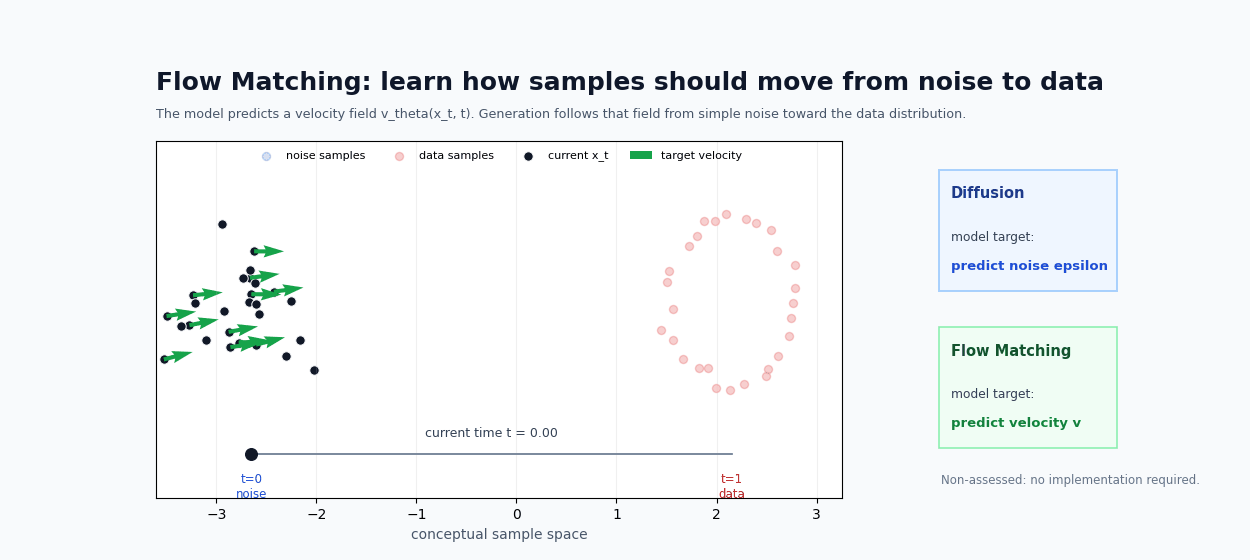


## Task 4: Diffusion vs Flow Matching Dynamics

This final mini-task uses the paper [Adjoint Matching: Fine-tuning Flow and Diffusion Generative Models with Memoryless Stochastic Optimal Control](https://arxiv.org/abs/2409.08861) only as research context. The paper treats diffusion and Flow Matching as dynamical generative models: both produce samples by transforming noise into data through an iterative process. You are **not** asked to implement Adjoint Matching, reward fine-tuning or stochastic optimal control.

The goal here is smaller but more hands-on: train two tiny 2D neural networks and make one figure that shows the basic difference between diffusion-style denoising and Flow Matching-style velocity transport.

### Problem Definition

Use the provided 2D toy dataset, tiny MLP, training loop and plotting code. Complete or inspect the TODO-marked formulas so the final figure compares:

1. The target data distribution.
2. A diffusion model trained to predict the noise added to a data point.
3. A Flow Matching model trained to predict the velocity from noise to data.

**What is provided**:

- A fixed eight-mode 2D toy dataset.
- A tiny time-conditioned MLP used by both methods.
- Fixed optimizer, learning rate, batch size and training budget.
- A DDIM-style deterministic sampler skeleton for the diffusion model.
- An Euler sampler skeleton for the Flow Matching model.
- Plotting code that saves the final comparison figure.

**What you must implement or check**:

- Diffusion forward noising and target: `x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon`, with target `epsilon`.
- Flow Matching interpolation and target: `x_t = (1 - t) * x_noise + t * x_data`, with target `x_data - x_noise`.
- Diffusion DDIM-style reverse update from predicted noise.
- Flow Matching Euler update from predicted velocity.

The notebook includes a working baseline implementation so that **Run all** still completes. Your task is to understand these TODO-marked lines and, if you edit them, keep the submitted figure consistent with the definitions above.

Do not change the MNIST dataset, the Task 2 conditional checkpoint, the Task 3 samplers, or any earlier evaluation code. This task does not use MNIST and does not submit a model file.

**Submission**:

Submit one figure with target data, training losses, generated samples and trajectories for both methods. The comparison-figure cell saves this file directly with the required CID name.

1. A comparison figure showing diffusion-style predicted-noise dynamics and Flow Matching predicted-velocity dynamics on the same 2D toy dataset.

    File Name: `CID_E9_T4_P5.png` (diffusion vs Flow Matching losses, samples and trajectories)

### Rerunnable Task 4 workflow

Run the setup/model/objective cell once. Then run the training/sampling/figure cell. Rerun both Task 4 cells if you change the Task 4 configuration values.


#### Setup, model and objective cell

The configuration block is the only place where you should change hyperparameters. The TODO-marked formulas are the conceptual core of the task: diffusion predicts noise, while Flow Matching predicts velocity.


In [ ]:
from pathlib import Path
import math
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

# Task 4 configuration: keep the task lightweight enough for Run all.
TASK4_RANDOM_SEED = 7
TASK4_NUM_DATA_POINTS = 1600
TASK4_BATCH_SIZE = 256
TASK4_TRAIN_STEPS = 1200
TASK4_LOG_EVERY = 10
TASK4_NUM_TRAJECTORIES = 16
TASK4_SAMPLE_STEPS = 32
TASK4_DIFFUSION_TIMESTEPS = 100
TASK4_LEARNING_RATE = 2e-3
TASK4_NOISE_SCALE = 1.2
TASK4_OUTPUT_PATH = Path("CID_E9_T4_P5.png")


def set_task4_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def task4_modes(device=None, radius=2.2):
    angles = torch.linspace(0, 2 * math.pi, 9, device=device)[:-1]
    return torch.stack([radius * torch.cos(angles), radius * torch.sin(angles)], dim=1)


def sample_task4_data(batch_size, device, std=0.09):
    modes = task4_modes(device)
    labels = torch.randint(0, modes.shape[0], (batch_size,), device=device)
    return modes[labels] + std * torch.randn(batch_size, 2, device=device)


def make_task4_numpy_data(num_points, seed):
    rng = np.random.default_rng(seed)
    angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)
    modes = np.stack([2.2 * np.cos(angles), 2.2 * np.sin(angles)], axis=1)
    labels = rng.integers(0, len(modes), size=num_points)
    points = modes[labels] + rng.normal(scale=0.09, size=(num_points, 2))
    return points, modes


class Task4TimeConditionedMLP(nn.Module):
    def __init__(self, hidden_dim=96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x, t):
        if t.ndim == 1:
            t = t[:, None]
        time_features = torch.cat([
            t,
            torch.sin(2 * math.pi * t),
            torch.cos(2 * math.pi * t),
            torch.sin(4 * math.pi * t),
        ], dim=1)
        return self.net(torch.cat([x, time_features], dim=1))


def task4_diffusion_schedule(num_timesteps, device):
    betas = torch.linspace(1e-4, 0.06, num_timesteps, device=device)
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    return alpha_bar


def task4_gather(values, indices, reference):
    return values[indices].view(-1, 1).to(reference.device)


def diffusion_noise_prediction_loss(model, x0, alpha_bar):
    batch_size = x0.shape[0]
    t_index = torch.randint(0, len(alpha_bar), (batch_size,), device=x0.device)
    t = t_index.float() / (len(alpha_bar) - 1)
    epsilon = torch.randn_like(x0)
    sqrt_alpha_bar_t = torch.sqrt(task4_gather(alpha_bar, t_index, x0))
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - task4_gather(alpha_bar, t_index, x0))

    # TODO 1: diffusion forward noising. The model input is a noisy point x_t.
    x_t = sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * epsilon

    # TODO 2: diffusion target. The diffusion model predicts the noise epsilon.
    target = epsilon

    prediction = model(x_t, t)
    return F.mse_loss(prediction, target)


def flow_matching_velocity_loss(model, x_data):
    batch_size = x_data.shape[0]
    x_noise = torch.randn_like(x_data) * TASK4_NOISE_SCALE
    t = torch.rand(batch_size, device=x_data.device)
    t_view = t[:, None]

    # TODO 3: Flow Matching interpolation between noise and data.
    x_t = (1.0 - t_view) * x_noise + t_view * x_data

    # TODO 4: Flow Matching target. The model predicts velocity along the path.
    target_velocity = x_data - x_noise

    prediction = model(x_t, t)
    return F.mse_loss(prediction, target_velocity)


#### Training, sampling and comparison-figure cell

Run this cell to train the two tiny models and save the required Task 4 figure. The generated figure is the only submission item for this mini-task.


In [ ]:
set_task4_seed(TASK4_RANDOM_SEED)
task4_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Task 4 device: {task4_device}")

alpha_bar_task4 = task4_diffusion_schedule(TASK4_DIFFUSION_TIMESTEPS, task4_device)
diffusion_toy_model = Task4TimeConditionedMLP().to(task4_device)
flow_toy_model = Task4TimeConditionedMLP().to(task4_device)

diffusion_optimizer = torch.optim.Adam(diffusion_toy_model.parameters(), lr=TASK4_LEARNING_RATE)
flow_optimizer = torch.optim.Adam(flow_toy_model.parameters(), lr=TASK4_LEARNING_RATE)

diffusion_loss_history = []
flow_loss_history = []
logged_steps = []

for step in range(1, TASK4_TRAIN_STEPS + 1):
    x_data = sample_task4_data(TASK4_BATCH_SIZE, task4_device)

    diffusion_optimizer.zero_grad()
    diffusion_loss = diffusion_noise_prediction_loss(diffusion_toy_model, x_data, alpha_bar_task4)
    diffusion_loss.backward()
    diffusion_optimizer.step()

    x_data = sample_task4_data(TASK4_BATCH_SIZE, task4_device)
    flow_optimizer.zero_grad()
    flow_loss = flow_matching_velocity_loss(flow_toy_model, x_data)
    flow_loss.backward()
    flow_optimizer.step()

    if step % TASK4_LOG_EVERY == 0 or step == 1:
        logged_steps.append(step)
        diffusion_loss_history.append(diffusion_loss.item())
        flow_loss_history.append(flow_loss.item())

    if step % 300 == 0:
        print(
            f"Task 4 step {step}/{TASK4_TRAIN_STEPS} - "
            f"diffusion loss: {diffusion_loss.item():.4f} - "
            f"flow loss: {flow_loss.item():.4f}"
        )


@torch.no_grad()
def sample_task4_diffusion(model, num_samples, num_steps, alpha_bar, device):
    model.eval()
    x = torch.randn(num_samples, 2, device=device) * TASK4_NOISE_SCALE
    paths = [x.detach().cpu().numpy()]
    indices = torch.linspace(len(alpha_bar) - 1, 0, num_steps + 1, device=device).round().long()

    for step in range(num_steps):
        t_index = indices[step].repeat(num_samples)
        previous_index = indices[step + 1].repeat(num_samples)
        t = t_index.float() / (len(alpha_bar) - 1)
        eps_hat = model(x, t)
        sqrt_alpha_bar_t = torch.sqrt(task4_gather(alpha_bar, t_index, x))
        sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - task4_gather(alpha_bar, t_index, x))
        sqrt_alpha_bar_prev = torch.sqrt(task4_gather(alpha_bar, previous_index, x))
        sqrt_one_minus_alpha_bar_prev = torch.sqrt(1.0 - task4_gather(alpha_bar, previous_index, x))

        # TODO 5: DDIM-style deterministic reverse update from predicted noise.
        x0_hat = (x - sqrt_one_minus_alpha_bar_t * eps_hat) / sqrt_alpha_bar_t
        x = sqrt_alpha_bar_prev * x0_hat + sqrt_one_minus_alpha_bar_prev * eps_hat
        paths.append(x.detach().cpu().numpy())

    return x.detach().cpu().numpy(), np.stack(paths, axis=0)


@torch.no_grad()
def sample_task4_flow(model, num_samples, num_steps, device):
    model.eval()
    x = torch.randn(num_samples, 2, device=device) * TASK4_NOISE_SCALE
    paths = [x.detach().cpu().numpy()]
    dt = 1.0 / num_steps

    for step in range(num_steps):
        t = torch.full((num_samples,), step / num_steps, device=device)
        velocity = model(x, t)

        # TODO 6: Euler update following the predicted Flow Matching velocity.
        x = x + dt * velocity
        paths.append(x.detach().cpu().numpy())

    return x.detach().cpu().numpy(), np.stack(paths, axis=0)


task4_data_np, task4_modes_np = make_task4_numpy_data(TASK4_NUM_DATA_POINTS, TASK4_RANDOM_SEED)
task4_diffusion_samples, task4_diffusion_paths = sample_task4_diffusion(
    diffusion_toy_model, TASK4_NUM_TRAJECTORIES, TASK4_SAMPLE_STEPS, alpha_bar_task4, task4_device
)
task4_flow_samples, task4_flow_paths = sample_task4_flow(
    flow_toy_model, TASK4_NUM_TRAJECTORIES, TASK4_SAMPLE_STEPS, task4_device
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=False, sharey=False)

axes[0, 0].scatter(task4_data_np[:, 0], task4_data_np[:, 1], s=7, alpha=0.42, color="black", linewidths=0)
axes[0, 0].scatter(task4_modes_np[:, 0], task4_modes_np[:, 1], s=90, marker="x", color="tab:red", linewidths=2)
axes[0, 0].set_title("Target data\n8 Gaussian modes")

axes[0, 1].plot(logged_steps, diffusion_loss_history, color="tab:blue")
axes[0, 1].set_title("Diffusion training\ntarget: noise epsilon")
axes[0, 1].set_xlabel("training step")
axes[0, 1].set_ylabel("MSE loss")
axes[0, 1].grid(alpha=0.25)

axes[0, 2].plot(logged_steps, flow_loss_history, color="tab:green")
axes[0, 2].set_title("Flow Matching training\ntarget: velocity")
axes[0, 2].set_xlabel("training step")
axes[0, 2].set_ylabel("MSE loss")
axes[0, 2].grid(alpha=0.25)

for axis in [axes[0, 0], axes[1, 0], axes[1, 1], axes[1, 2]]:
    axis.set_aspect("equal")
    axis.set_xlim(-3.5, 3.5)
    axis.set_ylim(-3.5, 3.5)
    axis.grid(alpha=0.18)
    axis.set_xlabel("x1")
    axis.set_ylabel("x2")

axes[1, 0].scatter(task4_data_np[:, 0], task4_data_np[:, 1], s=5, alpha=0.10, color="black", linewidths=0)
for path in np.moveaxis(task4_diffusion_paths, 1, 0):
    axes[1, 0].plot(path[:, 0], path[:, 1], color="tab:blue", alpha=0.42, linewidth=1.1)
axes[1, 0].scatter(task4_diffusion_paths[0, :, 0], task4_diffusion_paths[0, :, 1], s=18, color="tab:gray", label="noise start")
axes[1, 0].scatter(task4_diffusion_samples[:, 0], task4_diffusion_samples[:, 1], s=24, color="tab:blue", label="final sample")
axes[1, 0].set_title("Diffusion-style samples\nDDIM update from predicted noise")
axes[1, 0].legend(loc="lower left", fontsize=8, frameon=True)

axes[1, 1].scatter(task4_data_np[:, 0], task4_data_np[:, 1], s=5, alpha=0.10, color="black", linewidths=0)
for path in np.moveaxis(task4_flow_paths, 1, 0):
    axes[1, 1].plot(path[:, 0], path[:, 1], color="tab:green", alpha=0.52, linewidth=1.1)
axes[1, 1].scatter(task4_flow_paths[0, :, 0], task4_flow_paths[0, :, 1], s=18, color="tab:gray", label="noise start")
axes[1, 1].scatter(task4_flow_samples[:, 0], task4_flow_samples[:, 1], s=24, color="tab:green", label="final sample")
axes[1, 1].set_title("Flow Matching samples\nEuler update from predicted velocity")
axes[1, 1].legend(loc="lower left", fontsize=8, frameon=True)

axes[1, 2].scatter(task4_data_np[:, 0], task4_data_np[:, 1], s=5, alpha=0.08, color="black", linewidths=0)
for path in np.moveaxis(task4_diffusion_paths[:, :8, :], 1, 0):
    axes[1, 2].plot(path[:, 0], path[:, 1], color="tab:blue", alpha=0.32, linewidth=1.0)
for path in np.moveaxis(task4_flow_paths[:, 8:16, :], 1, 0):
    axes[1, 2].plot(path[:, 0], path[:, 1], color="tab:green", alpha=0.42, linewidth=1.0)
axes[1, 2].set_title("Two dynamics, same goal\nblue: noise prediction; green: velocity")

fig.suptitle("Task 4: diffusion predicts noise; Flow Matching predicts velocity", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(TASK4_OUTPUT_PATH, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved Task 4 figure to {TASK4_OUTPUT_PATH}")
print(f"Final logged diffusion loss: {diffusion_loss_history[-1]:.4f}")
print(f"Final logged Flow Matching loss: {flow_loss_history[-1]:.4f}")
